In [7]:
import yfinance as yf
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

In [9]:
gold = yf.download("GLD", start="2000-07-01", end="2025-07-01")
reit = yf.download("SCHH", start="2000-07-01", end="2025-07-01")
snp = yf.download("VOO", start="2000-07-01", end="2025-07-01")
iemg = yf.download("IEMG", start="2000-07-01", end="2025-07-01")
clean = yf.download("ICLN", start="2000-07-01", end="2025-07-01")
bio = yf.download("IBB", start="2000-07-01", end="2025-07-01")
ind = yf.download("VIS", start="2000-07-01", end="2025-07-01")
jd = yf.download("JD", start="2000-07-01", end="2025-07-01")
costco = yf.download("COST", start="2000-07-01", end="2025-07-01")
goog = yf.download("GOOGL", start="2000-07-01", end="2025-07-01")

/var/folders/11/bjv54wfn2gv8djxyjz2wfdjw0000gn/T/ipykernel_31080/413026339.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GLD", start="2000-07-01", end="2025-07-01")
[*********************100%***********************]  1 of 1 completed
/var/folders/11/bjv54wfn2gv8djxyjz2wfdjw0000gn/T/ipykernel_31080/413026339.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  reit = yf.download("SCHH", start="2000-07-01", end="2025-07-01")
[*********************100%***********************]  1 of 1 completed
/var/folders/11/bjv54wfn2gv8djxyjz2wfdjw0000gn/T/ipykernel_31080/413026339.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  snp = yf.download("VOO", start="2000-07-01", end="2025-07-01")
[*********************100%***********************]  1 of 1 completed
/var/folders/11/bjv54wfn2gv8djxyjz2wfdjw0000gn/T/ipykernel_31080/413026339.py:4: FutureWarning: YF.download() has chan

In [11]:
def change(stock, time):
    return((stock.iloc[-1]["Close"][stock["Close"].columns[0]] - stock.iloc[-time]["Close"][stock["Close"].columns[0]]) / stock.iloc[-time]["Close"][stock["Close"].columns[0]] * 100)
    
def beta(stock, time):
    X = snp.iloc[-time :]["Close"].pct_change().dropna()
    y = stock.iloc[-time :]["Close"].pct_change().dropna()

    data = pd.concat([X, y], axis=1).dropna()
    data.columns = ['market_return', 'stock_return']

    X = data[['market_return']]
    y = data['stock_return']

    model = LinearRegression()
    model.fit(X, y)

    coef = model.coef_[0]
    return coef
    
def expectedReturn(stock, time):
    return (4.250 + beta(stock, time) * (change(snp, time) - 4.250))
    
def alpha(stock, time):
    return (change(stock, time) - expectedReturn(stock, time))

def predPortfolioReturn(stocks, m, tm, time):
    percent = 0
    for i in range(len(stocks)):
        percent += expectedReturn(stocks[i], time) * m[i] / tm
    return percent

def actualReturn(stocks, wallet, time):
    percent = 0
    for i in range(len(stocks)):
        percent += change(stocks[i], time) * (wallet[i] / total)
    return percent

def portfolioDev(weights, portfolio, time):
    df = pd.DataFrame()
    for i in range(len(portfolio)):
        df = pd.concat([df, portfolio[i].iloc[-time :]["Close"].pct_change().dropna()], axis = 1)
    df = df[~np.isnan(df).any(axis=1)]
    cov = np.cov(df, rowvar = False)
    return (np.sqrt((weights.T @ cov @ weights) * 252) * 100)

def rollingPortfolioDev(weights, portfolio, start, span):
    frame = pd.DataFrame(columns = ['Date', 'STD'])
    for j in range(int(np.floor(len(portfolio[0]["Close"]) / span))):
        df = pd.DataFrame()
        for i in range(len(portfolio)):
            df = pd.concat([df, portfolio[i].iloc[start : start+span]["Close"].pct_change().dropna()], axis = 1)
        df = df[~np.isnan(df).any(axis=1)]
        if df.empty:
            continue

        cov = np.cov(df, rowvar = False)
        frame.loc[j] = [portfolio[0].iloc[start+span - 1].name, (np.sqrt((weights.T @ cov @ weights) * 252) * 100)[0][0]]
        start += span

    
    return(frame)

In [43]:
portfolio = [gold, reit, snp, iemg, clean, bio, ind, jd, costco, goog]
wallet = [5, 5, 25, 20, 6, 12, 12, 3, 5, 7]
#wallet = [0, 0, 100, 0, 0, 0, 0, 0, 0, 0]
days = 3650

period = round(days / (1.4484))

total = 0
for i in range(len(wallet)):
    total += wallet[i]

weights = np.zeros((len(wallet),1))
for i in range(len(wallet)):
    weights[i, 0] =  wallet[i] / total

print("Total Money: " + str(float(total)) + "$\n")

print("Estimated Return (CAPM): " + str(round(predPortfolioReturn(portfolio, wallet, total, period), 3)) + "%")
print("Portfolio Standard Deviation: " + str(round(portfolioDev(weights, portfolio, period)[0][0], 3)) + "%")
print("Predicted Portfolio Return ($): " + str(round(total * (1 + predPortfolioReturn(portfolio, wallet, total, period) / 100), 2)) + "$\n")

print("Predicted Return Range (1std -> 68%): " + str(round(predPortfolioReturn(portfolio, wallet, total, period) - portfolioDev(weights, portfolio, period)[0][0], 3)) + " to " + str(round(predPortfolioReturn(portfolio, wallet, total, period) + portfolioDev(weights, portfolio, period)[0][0], 3)) + "%")
print("Predicted Return Range (2std -> 95%): " + str(round(predPortfolioReturn(portfolio, wallet, total, period) - 2 * portfolioDev(weights, portfolio, period)[0][0], 3)) + " to " + str(round(predPortfolioReturn(portfolio, wallet, total, period) + 2 * portfolioDev(weights, portfolio, period)[0][0], 3)) + "%")
print("Sharpe Ratio: " + str(round((predPortfolioReturn(portfolio, wallet, total, period) - 4.250) / portfolioDev(weights, portfolio, period)[0][0], 3)) + "\n")

print("Actual Return (%): " + str(round(actualReturn(portfolio, wallet, period), 3)) + "%")
print("Actual Value ($): " + str(round(total * (1 + actualReturn(portfolio, wallet, period) / 100), 2)) + "$")

Total Money: 100.0$

Estimated Return (CAPM): 224.313%
Portfolio Standard Deviation: 17.399%
Predicted Portfolio Return ($): 324.31$

Predicted Return Range (1std -> 68%): 206.914 to 241.712%
Predicted Return Range (2std -> 95%): 189.516 to 259.111%
Sharpe Ratio: 12.648

Actual Return (%): 186.221%
Actual Value ($): 286.22$


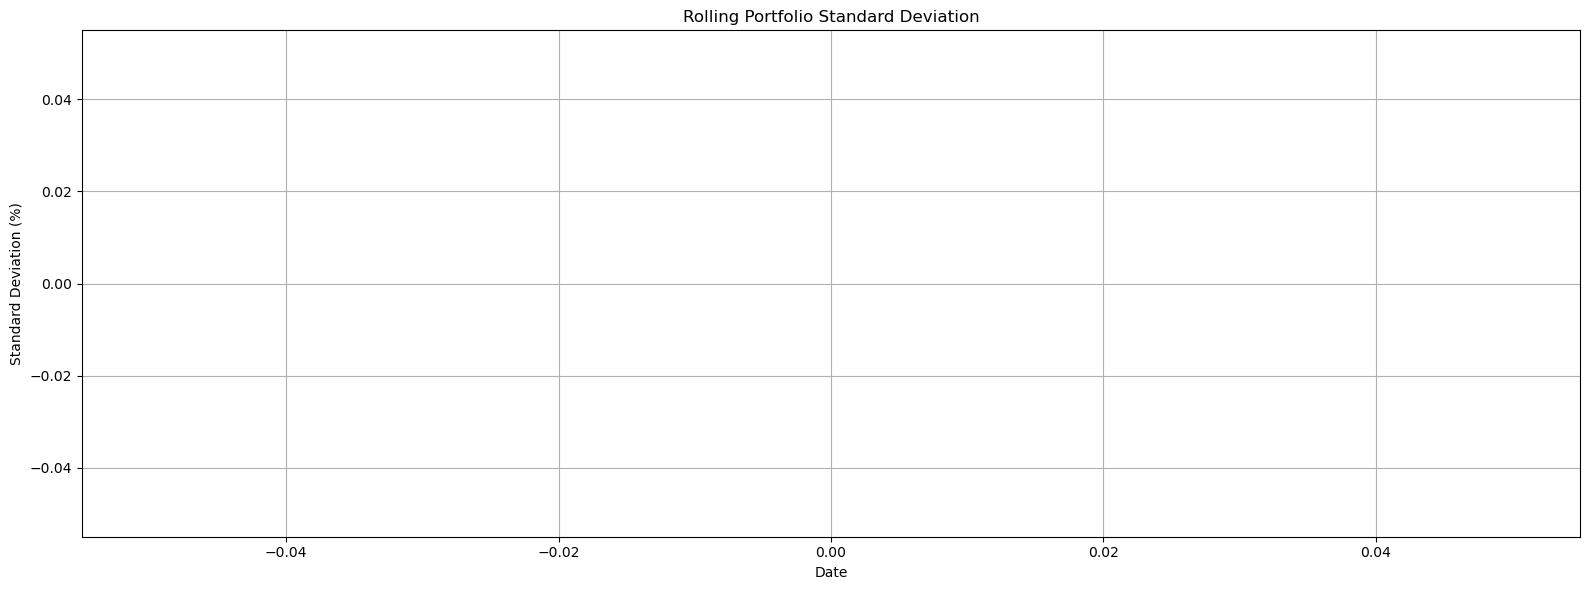

In [17]:
rollingStd = rollingPortfolioDev(weights, portfolio, -6000, period)
plt.figure(figsize=(16, 6))
plt.plot(rollingStd['Date'], rollingStd['STD'])
plt.title('Rolling Portfolio Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Standard Deviation (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

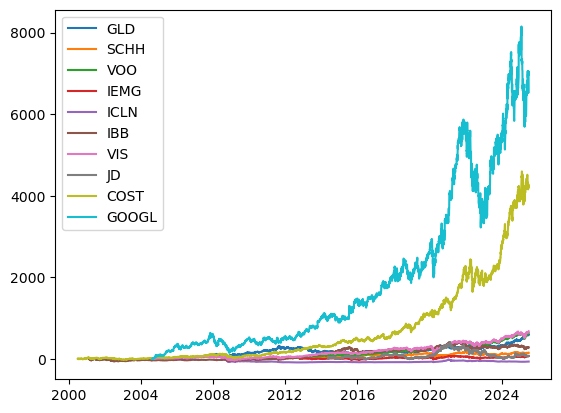

In [19]:
for i in range(len(portfolio)):
    normalized = portfolio[i]["Close"] / portfolio[i].iloc[0]["Close"] * 100 -100
    plt.plot(normalized, label = portfolio[i]["Close"].columns[0])
plt.legend()
plt.show()

# 